# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('airlines.csv')
train.head()

,airline_id,airline_name,alias,iata_code,icao_code,callsign,country,active
0,-1,Unknown,\N,-,NaN,\N,\N,Y
1,1,Private flight,\N,-,NaN,NaN,NaN,Y
2,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
3,10,40-Mile Air,\N,Q5,MLA,MILE-AIR,United States,Y
4,13,Ansett Australia,\N,AN,AAA,ANSETT,Australia,Y


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   airline_id    1536 non-null   int64
 1   airline_name  1536 non-null   str  
 2   alias         1198 non-null   str  
 3   iata_code     1534 non-null   str  
 4   icao_code     1261 non-null   str  
 5   callsign      1141 non-null   str  
 6   country       1527 non-null   str  
 7   active        1536 non-null   str  
dtypes: int64(1), str(7)
memory usage: 96.1 KB


In [4]:
print(
train.isnull().sum()
)

airline_id        0
airline_name      0
alias           338
iata_code         2
icao_code       275
callsign        395
country           9
active            0
dtype: int64


In [5]:
print(
train.isnull().sum()
)

airline_id        0
airline_name      0
alias           338
iata_code         2
icao_code       275
callsign        395
country           9
active            0
dtype: int64


In [6]:
d = train.describe()
d

,airline_id
count,1536.000000
mean,6568.774089
std,6465.912538
min,-1.000000
25%,1881.750000
50%,3777.000000
75%,10767.750000
max,21317.000000


C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_36464\2918027273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='active', ylabel='count'>

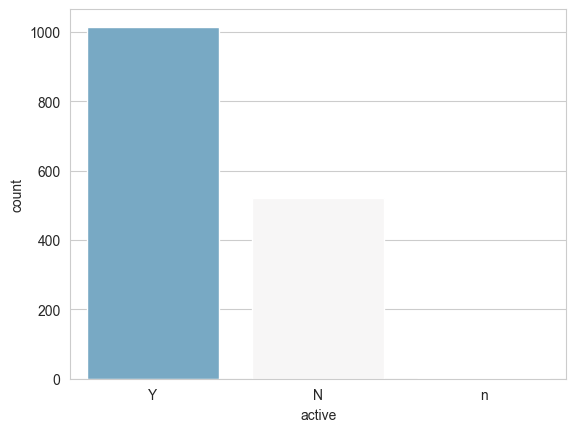

In [7]:
# Cek relative size dari active dan inactive
sns.set_style('whitegrid')

sns.countplot(
x='active',
data=train,
palette='RdBu_r'
)

<Axes: xlabel='count', ylabel='country'>

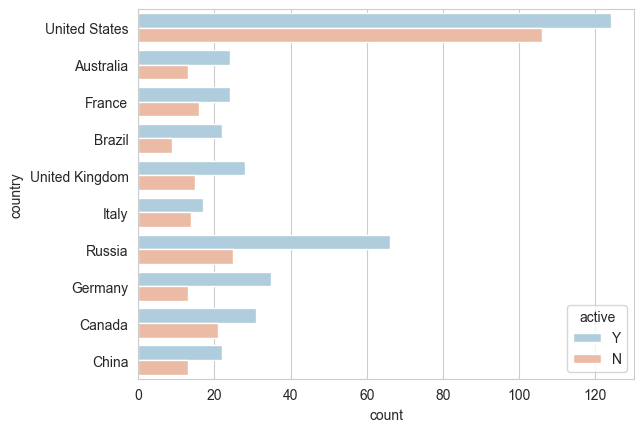

In [8]:
# Active vs Country
top_country = train[
'country'
].value_counts().nlargest(10).index

sns.set_style('whitegrid')

sns.countplot(
y='country',
hue='active',
data=train[
train['country'].isin(top_country)
],
palette='RdBu_r'
)

<Axes: xlabel='count', ylabel='country'>

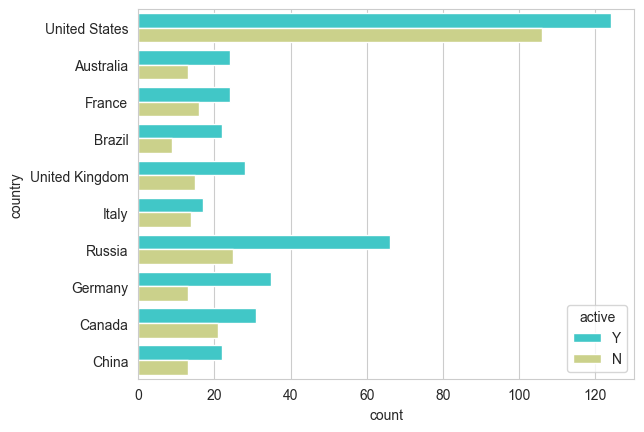

In [9]:
# Active vs Country
top_country = train[
'country'
].value_counts().nlargest(10).index

sns.set_style('whitegrid')

sns.countplot(
y='country',
hue='active',
data=train[
train['country'].isin(top_country)
],
palette='rainbow'
)

In [10]:
train['active'] = train['active'].map(
{'Y':1,'N':0}
)

In [11]:
f_country = train.groupby(
'country'
)['active'].mean()

In [12]:
top_country = train[
'country'
].value_counts().nlargest(10).index

<Axes: xlabel='count', ylabel='country'>

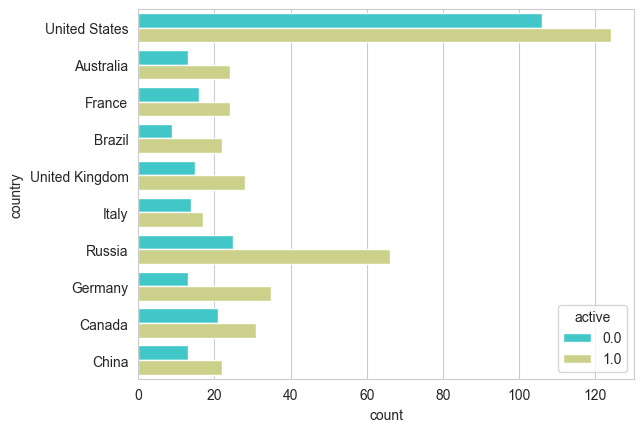

In [13]:
sns.countplot(
y='country',
hue='active',
data=train[
train['country'].isin(top_country)
],
palette='rainbow'
)

<Axes: title={'center': 'Histogram Airline ID'}, xlabel='Airline ID', ylabel='Count'>

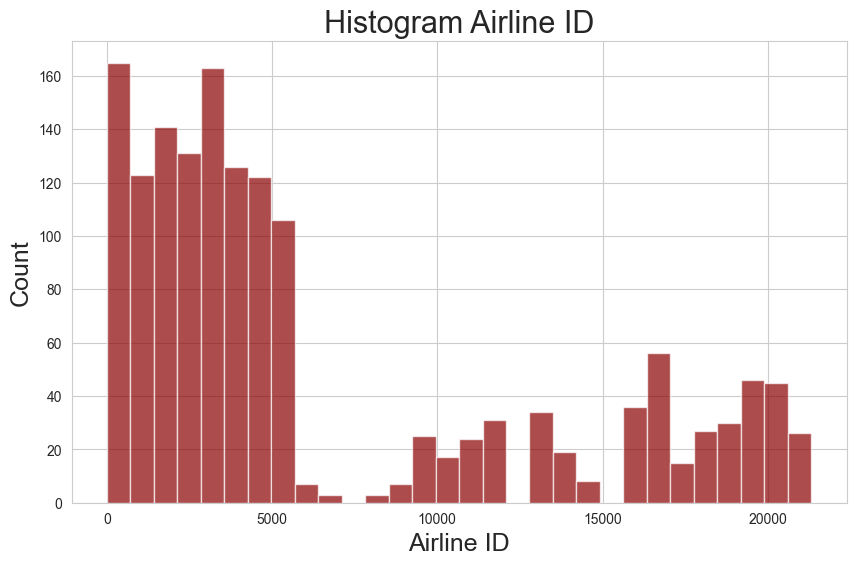

In [14]:
# Cek distribusi airline_id
plt.xlabel(
"Airline ID",
fontsize=18
)

plt.ylabel(
"Count",
fontsize=18
)

plt.title(
"Histogram Airline ID",
fontsize=22
)

train['airline_id'].hist(
bins=30,
color='darkred',
alpha=0.7,
figsize=(10,6)
)

C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_36464\2062846298.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Country', ylabel='Airline ID'>

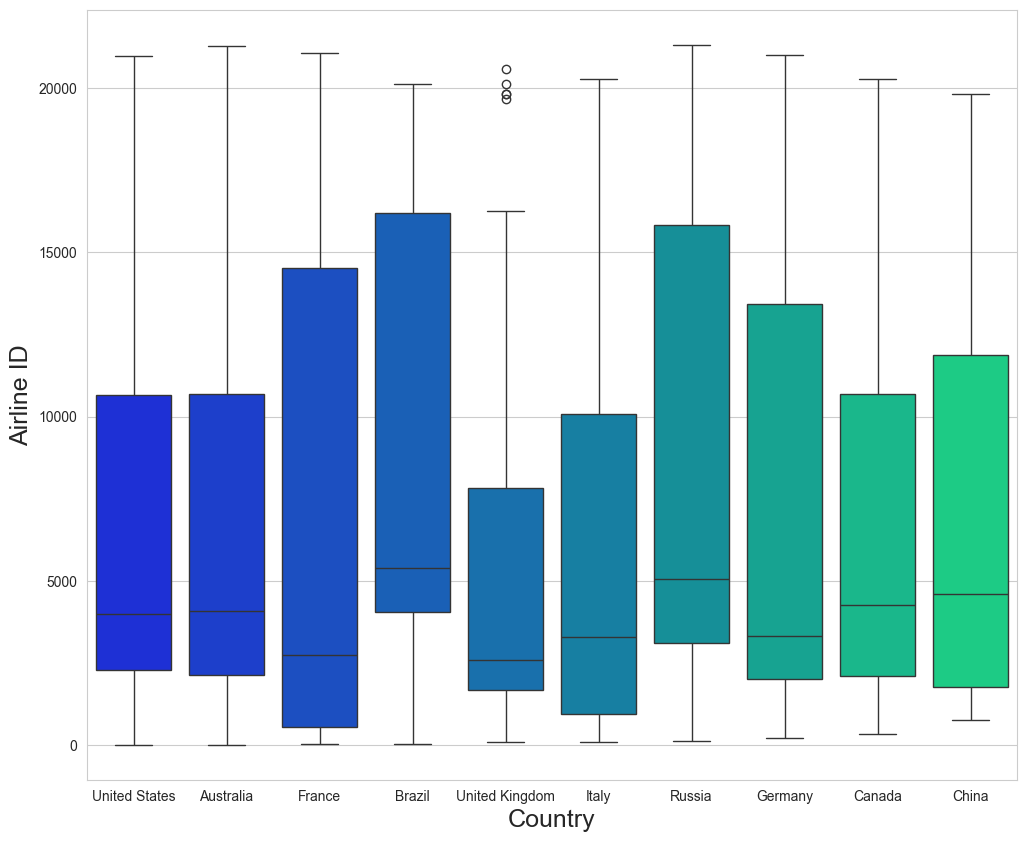

In [15]:
# Distribusi airline_id di setiap country
top_country = train[
'country'
].value_counts().nlargest(10).index

plt.figure(
figsize=(12,10)
)

plt.xlabel(
"Country",
fontsize=18
)

plt.ylabel(
"Airline ID",
fontsize=18
)

sns.boxplot(
x='country',
y='airline_id',
data=train[
train['country'].isin(top_country)
],
palette='winter'
)

Text(0.5, 0, 'Country')

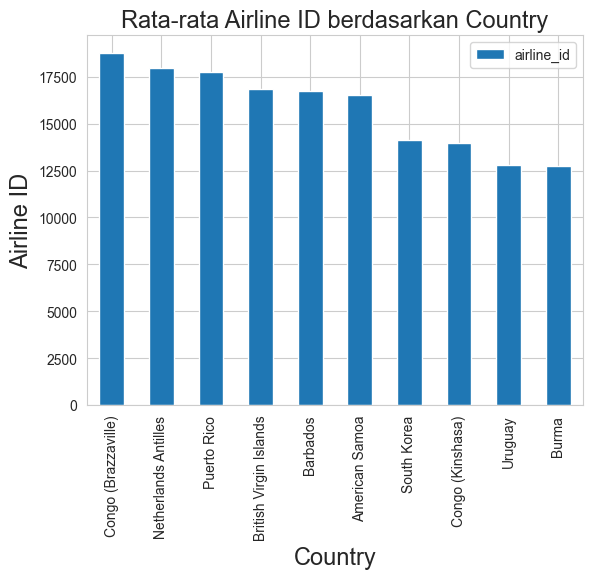

In [16]:
f_country = train.groupby(
'country'
)['airline_id'].mean()

f_country = pd.DataFrame(
f_country
)

f_country = f_country.sort_values(
by='airline_id',
ascending=False
).head(10)

f_country.plot.bar(
y='airline_id'
)

plt.title(
"Rata-rata Airline ID berdasarkan Country",
fontsize=17
)

plt.ylabel(
"Airline ID",
fontsize=17
)

plt.xlabel(
"Country",
fontsize=17
)

### Fitur Engineering

In [17]:
print(
train.isnull().sum()
)

airline_id        0
airline_name      0
alias           338
iata_code         2
icao_code       275
callsign        395
country           9
active            1
dtype: int64


In [18]:
train.drop(
['alias','icao_code','callsign'],
axis=1,
inplace=True
)

In [21]:
train['country'] = train['country'].fillna(train['country'].mode()[0])

In [22]:
train['iata_code'] = train['iata_code'].fillna(
'UNK'
)

In [24]:
train = train.dropna(
subset=['active']
)

In [25]:
print(
train.isnull().sum()
)

airline_id      0
airline_name    0
iata_code       0
country         0
active          0
dtype: int64


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

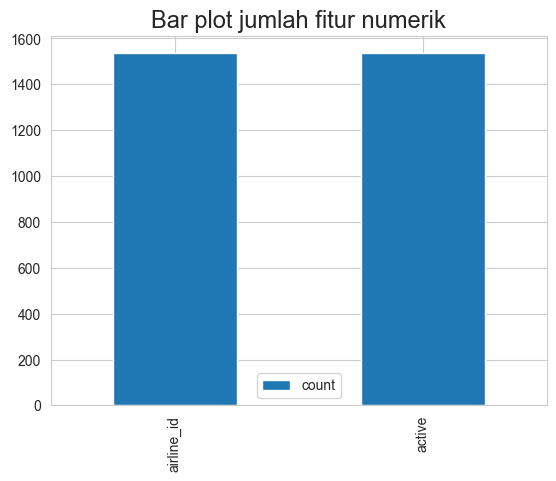

In [26]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [27]:
# drop kolom dengan banyak null
train.drop(
['alias','icao_code','callsign'],
axis=1,
inplace=True,
errors='ignore'
)

train.dropna(
inplace=True
)

train.head()

,airline_id,airline_name,iata_code,country,active
0,-1,Unknown,-,\N,1.0
1,1,Private flight,-,United States,1.0
2,3,1Time Airline,1T,South Africa,1.0
3,10,40-Mile Air,Q5,United States,1.0
4,13,Ansett Australia,AN,Australia,1.0


In [28]:
# Drop semua kolom yang tidak penting
train.drop(
['airline_name','iata_code'],
axis=1,
inplace=True,
errors='ignore'
)

train.head()

,airline_id,country,active
0,-1,\N,1.0
1,1,United States,1.0
2,3,South Africa,1.0
3,10,United States,1.0
4,13,Australia,1.0


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['country'] = le.fit_transform(
train['country']
)

train['active'] = le.fit_transform(
train['active']
)

train.head()

,airline_id,country,active
0,-1,201,1
1,1,192,1
2,3,168,1
3,10,192,1
4,13,12,1


### Training

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
train.drop(
'active',
axis=1
),
train['active'],
test_size=0.30,
random_state=42
)

In [31]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (1074, 2)
Test shape: (461, 2)


# **KNN**

In [32]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
y_pred = clf1.predict(X_test)

### Evaluation

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.62
Confusion Matrix:
[[ 40 111]
 [ 64 246]]
Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.26      0.31       151
           1       0.69      0.79      0.74       310

    accuracy                           0.62       461
   macro avg       0.54      0.53      0.53       461
weighted avg       0.59      0.62      0.60       461



# **Naive Bayes**

In [35]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [36]:
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.67
Confusion Matrix:
[[  0 151]
 [  0 310]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       151
           1       0.67      1.00      0.80       310

    accuracy                           0.67       461
   macro avg       0.34      0.50      0.40       461
weighted avg       0.45      0.67      0.54       461



c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

# **Decision Tree**

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [38]:
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.59
Confusion Matrix:
[[ 69  82]
 [109 201]]
Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.46      0.42       151
           1       0.71      0.65      0.68       310

    accuracy                           0.59       461
   macro avg       0.55      0.55      0.55       461
weighted avg       0.60      0.59      0.59       461



Krena yang lebih bagus adalah nilai evaluasinya model Decision Tree, maka kita akan tes menggunakan data baru

In [41]:
new_data = pd.DataFrame(
{
'airline_id':[1000],
'country':[5]
}
)

prediction = dt.predict(
new_data
)

print(
prediction[0]
)

0


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [42]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.65
Confusion Matrix:
[[ 53  98]
 [ 63 247]]
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.35      0.40       151
           1       0.72      0.80      0.75       310

    accuracy                           0.65       461
   macro avg       0.59      0.57      0.58       461
weighted avg       0.63      0.65      0.64       461



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.621035   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.621056   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.621048   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.610798   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.621982   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.603343   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.604269   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.619178   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.610793   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.617331   
4   {'metric': 'euclidean', 'n_neighbors

In [45]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [46]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [47]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.63
Presisi:  0.56
Recall:   0.56
F1-Score: 0.56

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.36      0.39       151
           1       0.71      0.76      0.73       310

    accuracy                           0.63       461
   macro avg       0.56      0.56      0.56       461
weighted avg       0.61      0.63      0.62       461

Confusion Matrix:
[[ 54  97]
 [ 75 235]]


In [49]:
import pandas as pd

new_data = pd.DataFrame(
{
'airline_id':[1000],
'country':[5]
}
)

prediction = best_model.predict(
new_data
)

print(
"Prediksi Active:",
prediction[0]
)

Prediksi Active: 1
